In [1]:
%load_ext autoreload
%autoreload 

import pandas as pd
import os
import sklearn
from sklearn.metrics import balanced_accuracy_score, accuracy_score, roc_auc_score
from scipy.special import softmax
from scipy.stats import linregress, t
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yaml
import torch
from src.utils.analysis_utils import *

/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
# =============================================================
# CONFIGURATION
# =============================================================

# Root directory of this repository
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

# Where processed results are stored (download from data repository — see README)
RESULTS_DIR = os.path.join(BASE_DIR, 'processed_results')
RESULTS_DIR = os.path.join('/well/papiez/users/hri611/python/data-centric-bias', 'processed_results')

# Where to save output figures
FIGS_DIR = os.path.join(BASE_DIR, 'final_figs')
os.makedirs(FIGS_DIR, exist_ok=True)


In [99]:
plt.rcParams.update({
    "font.size": 14,       # base font size
    "axes.titlesize": 18,  # title
    "axes.labelsize": 16,  # axis labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 16
})

# MNIST

In [ ]:
PRETRAINED=True
dataset='MNIST'
label='parity'
model = 'mlp'

test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, f'data/MNIST/{label}/test_labels.csv'))
test_metadata_df['id'] = test_metadata_df['image_index']

attributes = ["S","A", "Random_binary"]

# Experiment type: choose one
experiment_string = 'llrt_alloc'          # LLRT (main experiments)
# experiment_string = 'finetune_alloc'    # Full fine-tuning
# experiment_string = 'scratch_alloc'     # Training from scratch

required_lr = 0.001587
required_data_name = label

emd_df = pd.read_csv(os.path.join(RESULTS_DIR, 'mnist/pretrain_mean_distances_correct_pcs_stds.csv'))
emd_df['subgroup'] = emd_df['Unnamed: 0']


In [4]:
all_runs_df, summary_df = get_summary_df(experiment_string, test_metadata_df, required_lr, required_data_name, attributes)

## Allocation sensitivity

/tmp/slurm-14602392/ipykernel_3704284/3002167629.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgroup_df.sort_values(by='proportion', inplace=True)


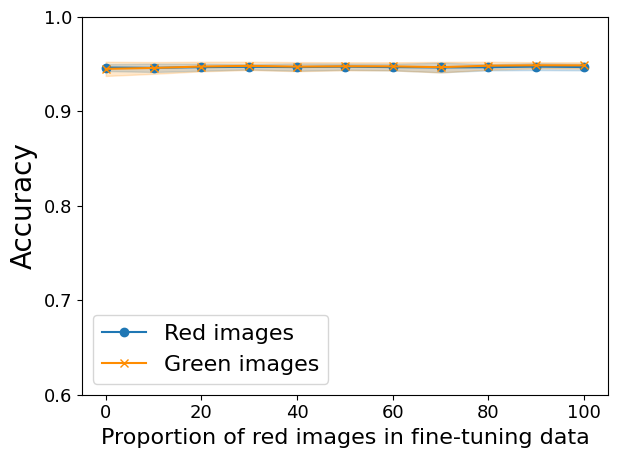

In [5]:
# metric = 'auc'
metric = 'balanced_acc'
# metric = 'loss'

min_val = min(all_runs_df[metric+'_group_0'].min(), all_runs_df[metric+'_group_1'].min())
max_val = max(all_runs_df[metric+'_group_0'].max(), all_runs_df[metric+'_group_1'].max())

subgroup = 'S'
unique_subgroups = summary_df['subgroup'].unique()
titles = ['Under 5 / over 5 subgroups', 'Random subgroups', 'Red / green subgroups']

subgroup_df = summary_df[summary_df['subgroup'] == subgroup]
subgroup_df.sort_values(by='proportion', inplace=True)

x = subgroup_df['proportion']
y0 = subgroup_df[(metric+'_group_0','mean')]
std0 = subgroup_df[(metric+'_group_0','std')]
y1 = subgroup_df[(metric+'_group_1','mean')]
std1 = subgroup_df[(metric+'_group_1','std')]


plt.plot(x, y0, label='Red images', marker='o', color='#1f77b4')
plt.fill_between(x, y0 - std0, y0 + std0, alpha=0.2, color='#1f77b4')

plt.plot(x, y1, label='Green images', marker='x', color='darkorange')
plt.fill_between(x, y1 - std1, y1 + std1, alpha=0.2, color='darkorange')

plt.legend()
plt.xlabel('Proportion of red images in fine-tuning data')
plt.ylabel('Accuracy',size=20)
    # plt.xlim(10,90)

plt.ylim(0.6,1.0)
plt.yticks([0.6,0.7,0.8,0.9,1.0])
    # plt.title()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, f'mnist_{subgroup}_{metric}_alloc.pdf'))
plt.show()

/tmp/slurm-14602392/ipykernel_3704284/4232056441.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgroup_df.sort_values(by='proportion', inplace=True)


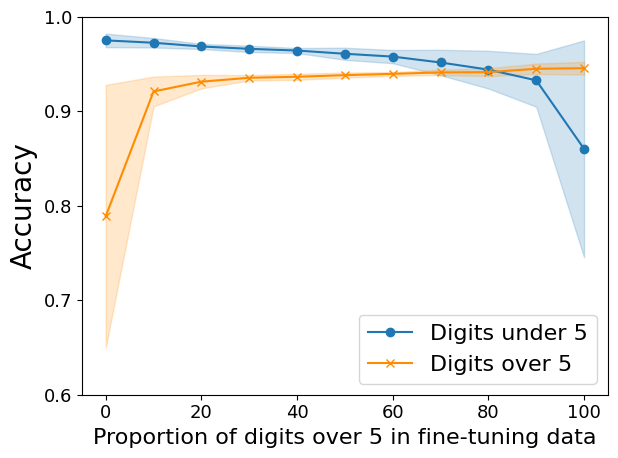

In [6]:
subgroup = 'A'
unique_subgroups = summary_df['subgroup'].unique()
titles = ['Under 5 / over 5 subgroups', 'Random subgroups', 'Red / green subgroups']

subgroup_df = summary_df[summary_df['subgroup'] == subgroup]
subgroup_df.sort_values(by='proportion', inplace=True)

x = subgroup_df['proportion']
y0 = subgroup_df[(metric+'_group_0','mean')]
std0 = subgroup_df[(metric+'_group_0','std')]
y1 = subgroup_df[(metric+'_group_1','mean')]
std1 = subgroup_df[(metric+'_group_1','std')]


plt.plot(x, y0, label='Digits under 5', marker='o', color='#1f77b4')
plt.fill_between(x, y0 - std0, y0 + std0, alpha=0.2, color='#1f77b4')

plt.plot(x, y1, label='Digits over 5', marker='x', color='darkorange')
plt.fill_between(x, y1 - std1, y1 + std1, alpha=0.2, color='darkorange')

plt.legend()
plt.xlabel('Proportion of digits over 5 in fine-tuning data')
plt.ylabel('Accuracy',size=20)
    # plt.xlim(10,90)

plt.ylim(0.6,1.0)
plt.yticks([0.6,0.7,0.8,0.9,1.0])
    # plt.title()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, f'mnist_{subgroup}_{metric}_alloc.pdf'))
plt.show()

## Plot upper bound

In [7]:
metrics = ['auc', 'balanced_acc','acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()

slopes_df = get_slopes_df(all_runs_df, metrics, subgroups)

In [8]:
slopes_df = slopes_df.merge(emd_df,on='subgroup')
slopes_df = slopes_df.rename(columns={col: col.replace("FID", "FD") for col in slopes_df.columns if "FID" in col})
slopes_df = slopes_df.rename(columns={col: col.replace("TVD", "TV") for col in slopes_df.columns if "TVD" in col})

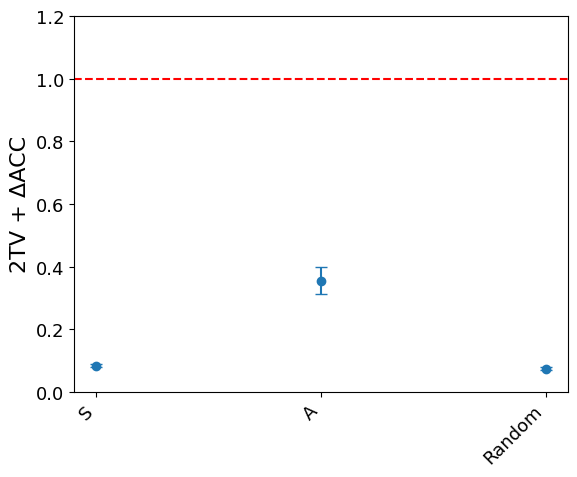

In [9]:
slopes_df['2TV+Δacc_mean'] = 2 * slopes_df['TV_g0_vs_g1_mean'] + slopes_df['balanced_acc_diff_mean']
slopes_df['2TV+Δacc_std']  = (2 * slopes_df['TV_g0_vs_g1_std']**2 + slopes_df['balanced_acc_diff_std']**2)**0.5  # rough propagated std
plt.figure(figsize=((6,5)))
plt.errorbar(slopes_df['subgroup'], slopes_df['2TV+Δacc_mean'],
             yerr=slopes_df['2TV+Δacc_std'], fmt='o', capsize=4)

plt.axhline(1.0, color='r', linestyle='--', label='bound = 1')
plt.ylabel('2TV + ΔACC')
plt.ylim([0,1.2])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'upperbound_mnist.pdf'), dpi=200,bbox_inches='tight')
plt.show()



# MIMIC

In [ ]:
PRETRAINED=True
dataset='MIMIC'
label='Pleural_Effusion'
model = 'densenet'

test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, f'data/MIMIC/{label}/test_labels.csv.gz'))
test_metadata_df['id'] = test_metadata_df['dicom_id']

attributes = ["ViewPosition_binary", "PatientOrientationCodeSequence_CodeMeaning_binary",
              "PerformedProcedureStepDescription_binary", "Support_Devices_binary",
              "Gender_binary", "Insurance_binary", "Language_binary",
              "Marital_Status_binary", "Race_cat_binary", "Age_binary", "Random_binary"]

# Experiment type: choose one
experiment_string = 'llrt_alloc'          # LLRT (main experiments)
# experiment_string = 'finetune_alloc'    # Full fine-tuning
# experiment_string = 'scratch_alloc'     # Training from scratch

if experiment_string == 'scratch_alloc':
    required_lr = 0.000158
    emd_df = pd.read_csv(os.path.join(RESULTS_DIR, f'mimic/{model}/{label.lower()}/scratch_mean_distances.csv'))
else:  # LLRT or full fine-tuning
    required_lr = 0.0006
    emd_df = pd.read_csv(os.path.join(RESULTS_DIR, f'mimic/{model}/{label.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))
emd_df['subgroup'] = emd_df['Unnamed: 0']

required_data_name = label
train_df = pd.read_csv(os.path.join(BASE_DIR, 'data/MIMIC/Pleural_Effusion/train_labels_pretrain.csv.gz'))


In [107]:
all_runs_df, summary_df = get_summary_df(experiment_string, test_metadata_df, required_lr, required_data_name, attributes)

Skipping: logs/llrt_alloc_ViewPosition_binary_0/runs/2025-09-18_21-13-47-837139/preds.csv
Skipping: logs/llrt_alloc_ViewPosition_binary_10/runs/2025-09-18_21-00-20-393065/preds.csv
Skipping: logs/llrt_alloc_ViewPosition_binary_40/runs/2025-09-18_21-17-49-250417/preds.csv
Skipping: logs/llrt_alloc_ViewPosition_binary_60/runs/2025-09-18_22-02-03-447013/preds.csv
Skipping: logs/llrt_alloc_ViewPosition_binary_70/runs/2025-09-18_21-57-08-630950/preds.csv
Skipping: logs/llrt_alloc_ViewPosition_binary_80/runs/2025-09-18_22-20-58-067201/preds.csv
Skipping: logs/llrt_alloc_ViewPosition_binary_90/runs/2025-09-18_22-04-19-710807/preds.csv
Skipping: logs/llrt_alloc_PatientOrientationCodeSequence_CodeMeaning_binary_40/runs/2025-09-19_04-54-16-957794/preds.csv
Skipping: logs/llrt_alloc_PerformedProcedureStepDescription_binary_30/runs/2025-09-19_13-38-29-178942/preds.csv
Skipping: logs/llrt_alloc_PerformedProcedureStepDescription_binary_60/runs/2025-09-19_13-42-48-480150/preds.csv
Skipping: logs/llrt

## Allocation sensitivity

/gpfs3/well/papiez/users/hri611/python/data-centric-bias/src/utils/analysis_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgroup_df.sort_values(by='proportion', inplace=True)


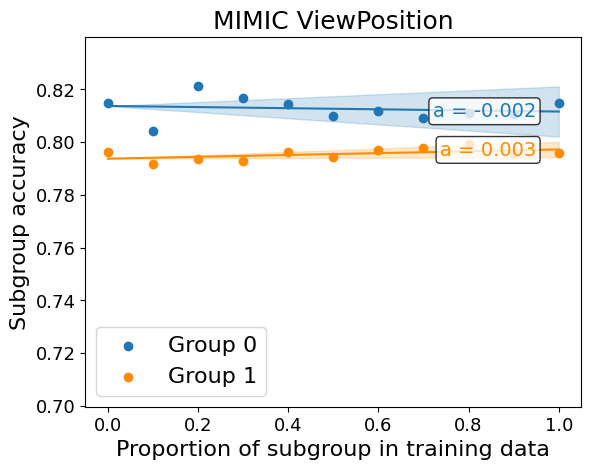

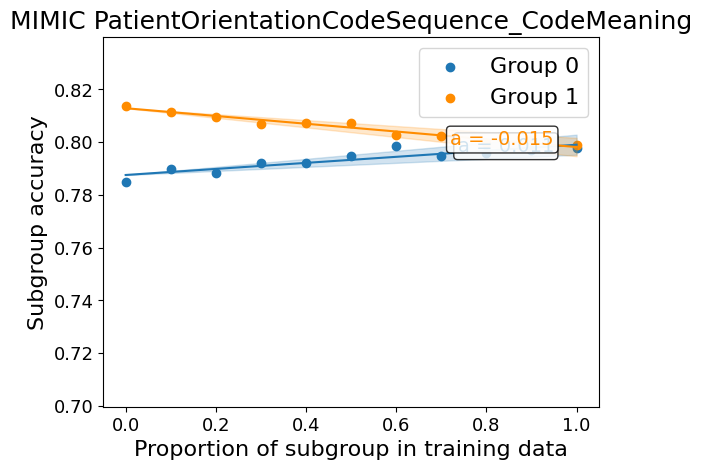

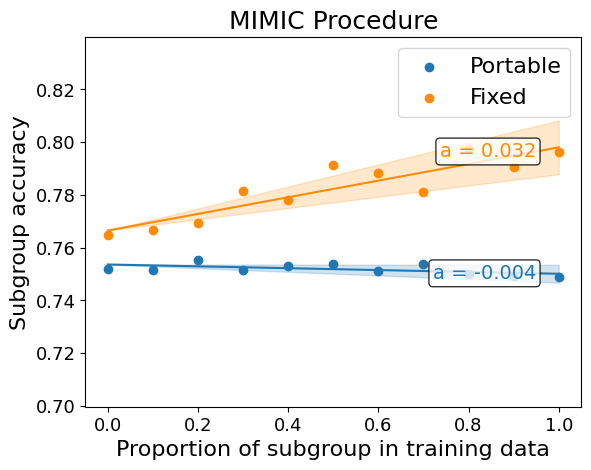

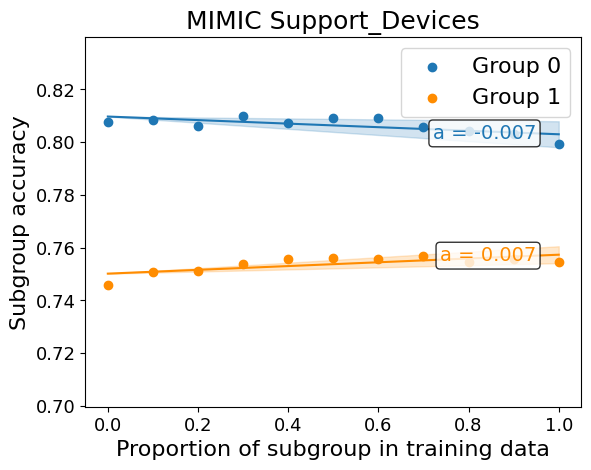

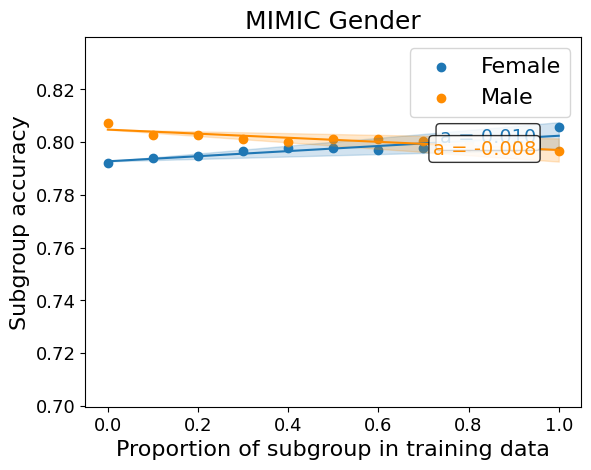

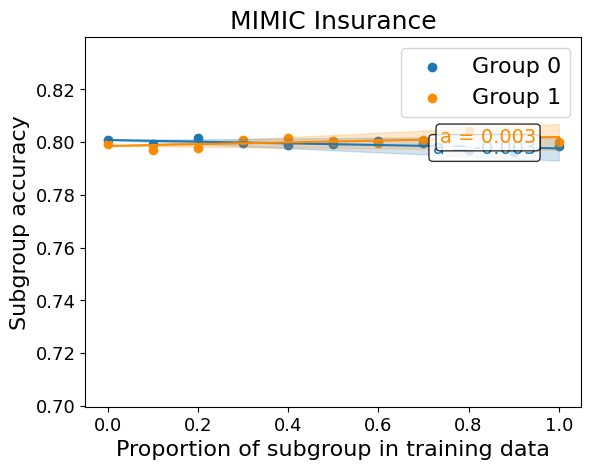

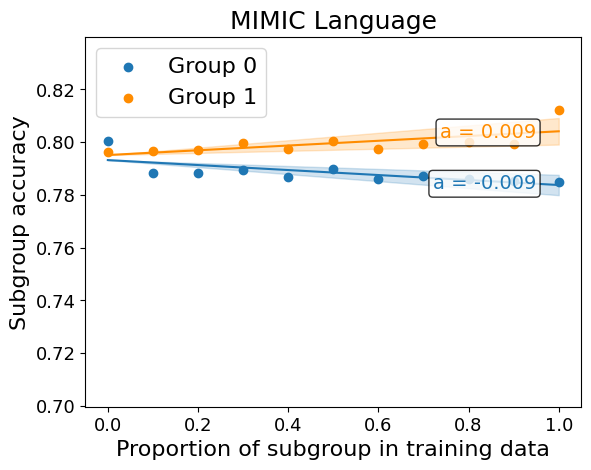

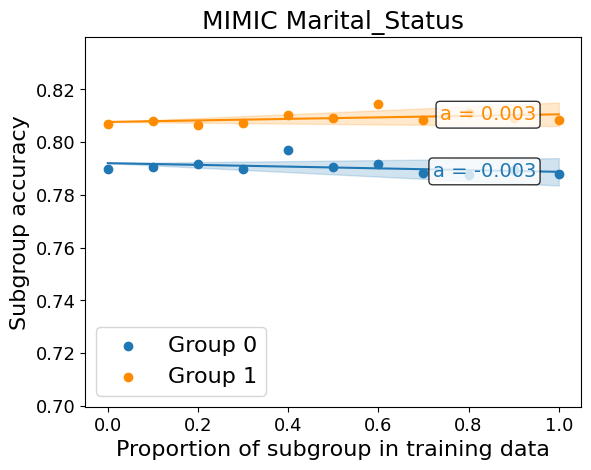

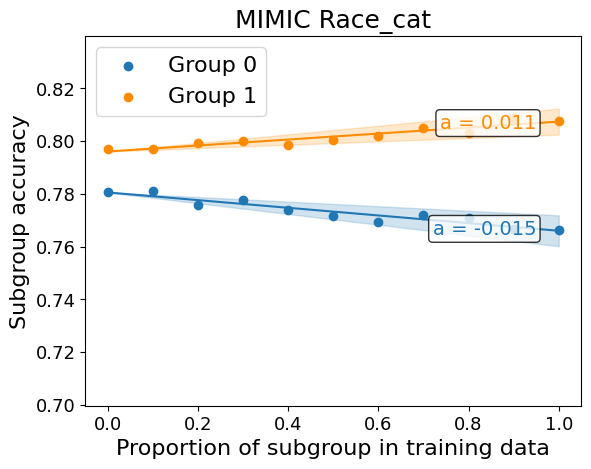

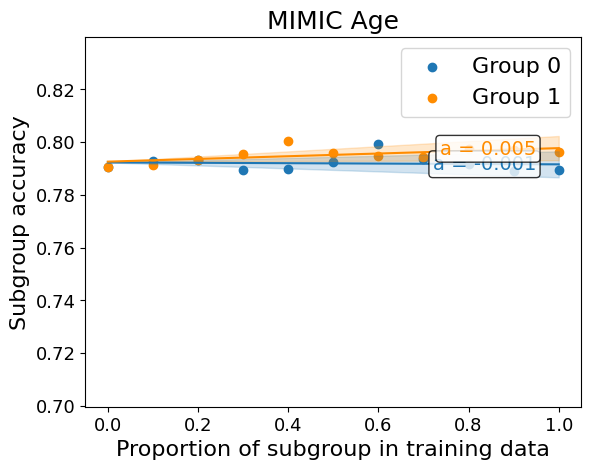

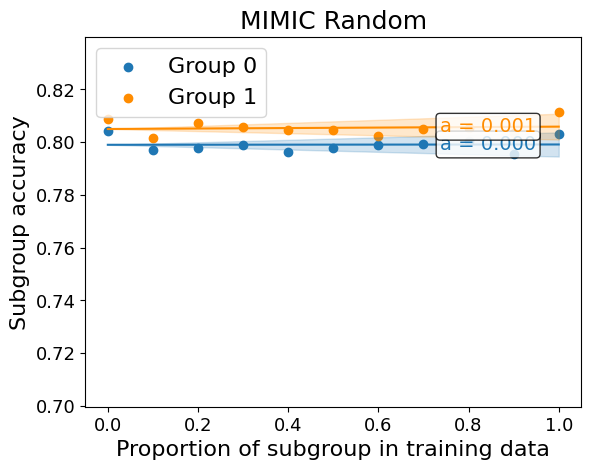

In [108]:
metric = 'balanced_acc'

min_val = min(all_runs_df[metric+'_group_0'].min(), all_runs_df[metric+'_group_1'].min())
max_val = max(all_runs_df[metric+'_group_0'].max(), all_runs_df[metric+'_group_1'].max())

filtered_df = all_runs_df.copy()

plot_slope(filtered_df, summary_df, metric, min_val, max_val, dataset)

In [ ]:
metrics = ['auc', 'balanced_acc','acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()

slopes_df = get_slopes_df(all_runs_df, metrics, subgroups)

In [93]:
slopes_df = slopes_df.merge(emd_df,on='subgroup')
slopes_df = slopes_df.rename(columns={col: col.replace("FID", "FD") for col in slopes_df.columns if "FID" in col})
slopes_df = slopes_df.rename(columns={col: col.replace("TVD", "TV") for col in slopes_df.columns if "TVD" in col})

In [95]:
slopes_df = slopes_df[slopes_df['subgroup']!='PatientOrientationCodeSequence_CodeMeaning'] # drop bc of low sample size

## Correlation: representation distance vs allocation sensitivity

Also look at correlation between loss slope and generalisation (full shot performance minus zero shot performance).

0.0006449970371474015
0.0012934781807821844
0.004612164082241086


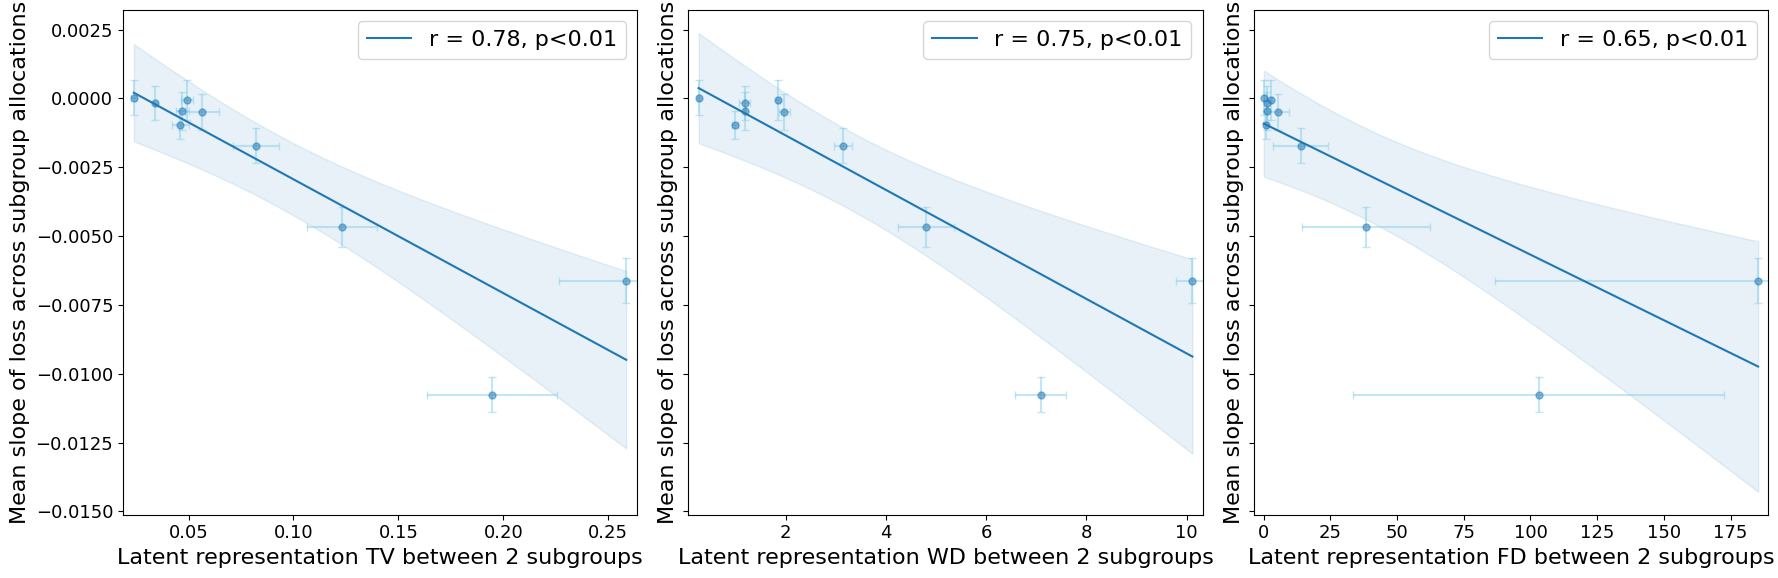

2.3181408041248746e-05
0.00010027426773274816
0.00021714704194011878


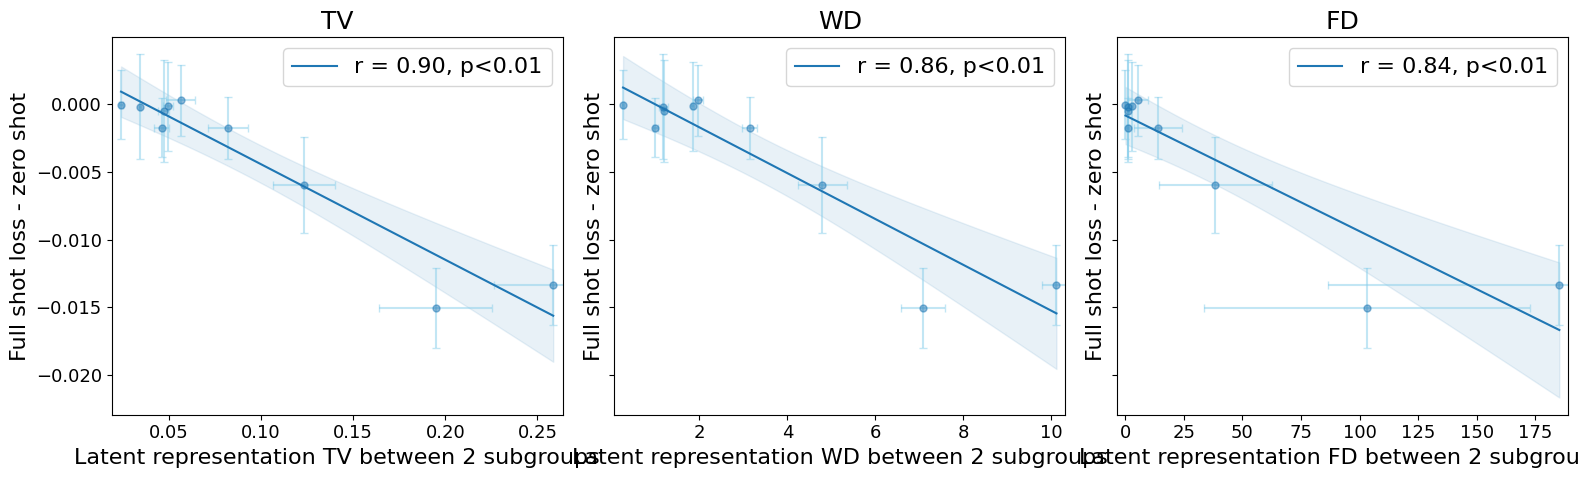

In [60]:
distance_metrics = ['TV','WD','FD']
metric = 'loss'
# with 80% variance

plot_distance_slope(slopes_df, distance_metrics,metric)
plot_distance_generalisation(slopes_df, distance_metrics,metric)

In [26]:
slopes_df['subgroup'] = slopes_df['subgroup'].replace({
    'PatientOrientationCodeSequence_CodeMeaning': 'Orientation',
    'PerformedProcedureStepDescription': 'Procedure',
    'Support_Devices':'Devices',
    'Marital_Status': 'Married'
})

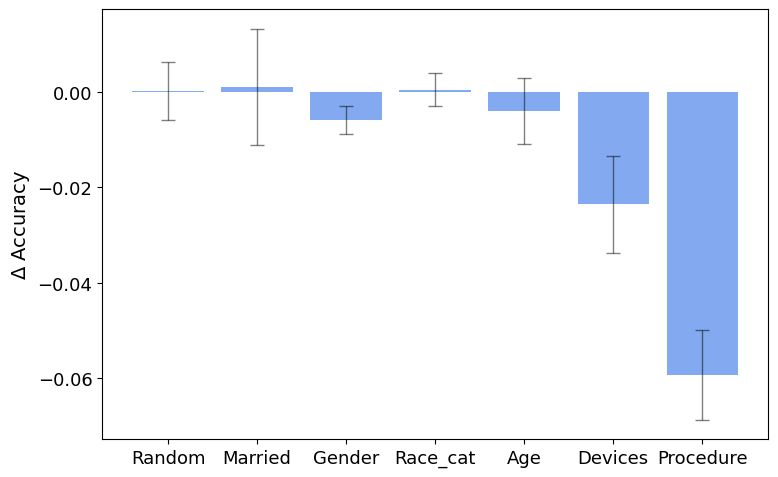

In [136]:
metric = 'balanced_acc'  # can also be 'auc' or 'balanced_acc'

diff_col = f'{metric}_diff_mean'
std_col = f'{metric}_diff_std'

# Sort subgroups by WD_g0_vs_g1_mean
sorted_df = slopes_df.sort_values('TV_g0_vs_g1_mean')
# sorted_df.set_index('subgroup',inplace=True)
x_pos = np.arange(len(sorted_df))
plt.figure(figsize=(8, 5))
plt.bar(x_pos, -sorted_df[diff_col], yerr=sorted_df[std_col], 
        capsize=5, color='cornflowerblue', alpha=0.8,error_kw={'alpha':0.5, 'lw':1})
# y_arrow = min(-sorted_df[diff_col]) - 0.01  # position below bars
plt.ylabel(f'$\Delta$ Accuracy')
plt.tight_layout()
plt.xticks(x_pos, sorted_df['subgroup'], rotation=0)
# plt.title('Civil_comments')
plt.savefig(os.path.join(FIGS_DIR, 'scratch_mimic_bacc.pdf'),bbox_inches="tight")

plt.show()

## Alternative hypotheses

In [21]:
base_dir = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
required_lr = 0.000158

summary_gap_df = get_baseline_subgroup_df(base_dir,test_metadata_df,attributes,required_lr)
summary_gap_df['subgroup'] = summary_gap_df['subgroup'].str.replace("_binary", "", regex=False)
# summary_gap_df['subgroup'] = summary_gap_df['subgroup'].replace({
#     'PatientOrientationCodeSequence_CodeMeaning': 'Orientation',
#     'PerformedProcedureStepDescription': 'Procedure',
#     'Support_Devices':'Devices'
# })


slopes_df = slopes_df.merge(summary_gap_df,on='subgroup')

In [22]:
group_1_prevalence = []
group_0_prevalence = []
class_prevalence_diffs = []
class_prevalence_group_1 = []
class_prevalence_group_0 = []

for col in slopes_df['subgroup'].tolist():
    subgroup_1_df = train_df[train_df[col + '_binary'] == 1]
    subgroup_0_df = train_df[train_df[col + '_binary'] == 0]

    # fraction of dataset belonging to group 1 vs group 0
    group_1_prevalence.append(len(subgroup_1_df) / len(train_df))
    group_0_prevalence.append(len(subgroup_0_df) / len(train_df))

    # within-group class prevalences
    prev_1 = len(subgroup_1_df[subgroup_1_df['Y'] == 1]) / len(subgroup_1_df)
    prev_0 = len(subgroup_0_df[subgroup_0_df['Y'] == 1]) / len(subgroup_0_df)

    class_prevalence_group_1.append(prev_1)
    class_prevalence_group_0.append(prev_0)

    # absolute difference in positive class prevalence between groups
    class_prevalence_diffs.append(np.abs(prev_1 - prev_0))

slopes_df['group_1_prevalence'] = group_1_prevalence
slopes_df['group_0_prevalence'] = group_0_prevalence
slopes_df['mean_prevalence'] = [np.abs(x-0.5) for x in group_1_prevalence] # gives indication of whether there is imbalance
slopes_df['class_prevalence_group_1'] = class_prevalence_group_1
slopes_df['class_prevalence_group_0'] = class_prevalence_group_0
slopes_df['class_prevalence_diff'] = class_prevalence_diffs

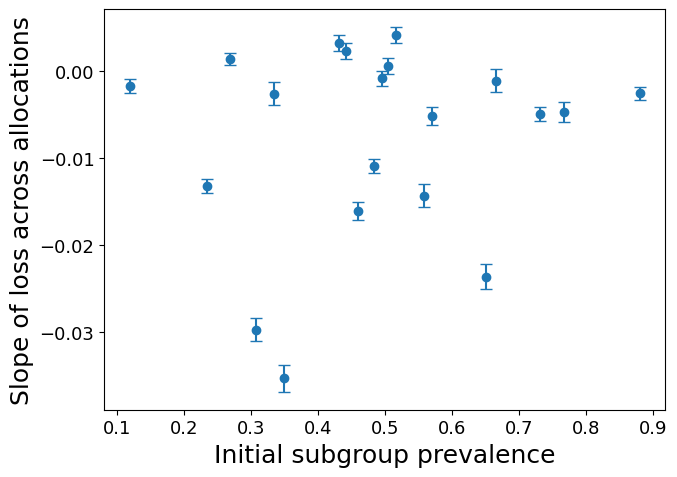

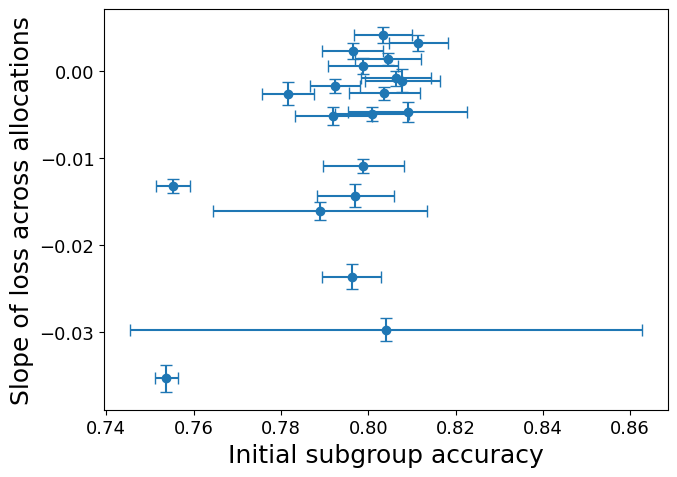

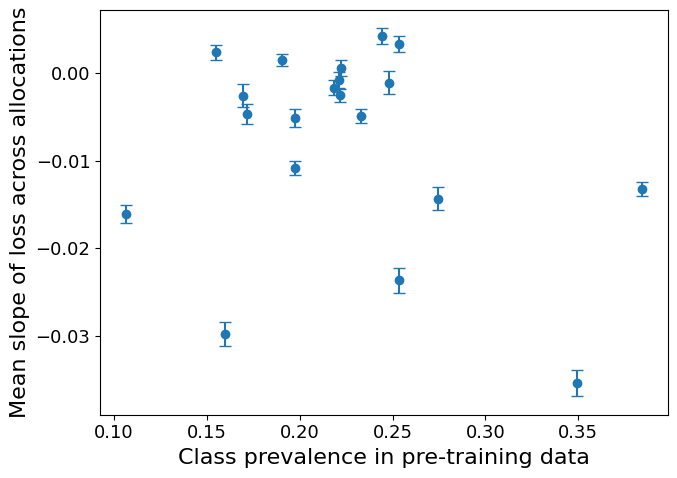

In [29]:
metric = "loss"  # or "balanced_acc", etc.
plt.figure(figsize=(7, 5))

plt.errorbar(
    slopes_df['group_0_prevalence'],
    slopes_df[f'{metric}_slope_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['group_1_prevalence'],
    slopes_df[f'{metric}_slope_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.xlabel("Initial subgroup prevalence",size=18)
plt.ylabel(f"Slope of {metric} across allocations",size=18)
# plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fullft_mimic_prevalence.pdf'),bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(
    slopes_df['mean_balanced_acc_group_0'],
    slopes_df[f'{metric}_slope_group_0'],
    xerr=slopes_df['std_balanced_acc_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['mean_balanced_acc_group_1'],
    slopes_df[f'{metric}_slope_group_1'],
    xerr=slopes_df['std_balanced_acc_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.ylabel(f"Slope of {metric} across allocations",size=18)
plt.xlabel("Initial subgroup accuracy",size=18)
# plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fullft_mimic_imbalance.pdf'),bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))

plt.errorbar(
    slopes_df['class_prevalence_group_0'],
    slopes_df[f'{metric}_slope_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['class_prevalence_group_1'],
    slopes_df[f'{metric}_slope_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.xlabel("Class prevalence in pre-training data")
plt.ylabel(f"Mean slope of {metric} across allocations")
# plt.legend()
plt.tight_layout()
# plt.title('Civil_comments')
plt.savefig(os.path.join(FIGS_DIR, 'fullft_mimic_class_prevalence.pdf'),bbox_inches="tight")
plt.show()

## Upper bound

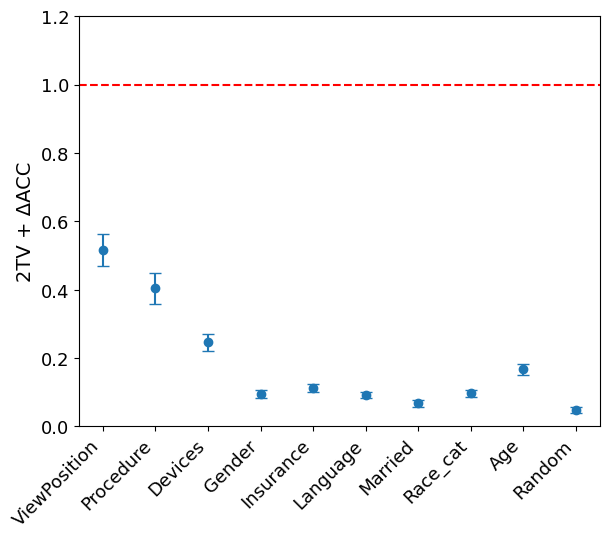

In [173]:
slopes_df['2TV+Δacc_mean'] = 2 * slopes_df['TV_g0_vs_g1_mean'] + slopes_df['balanced_acc_diff_mean']
slopes_df['2TV+Δacc_std']  = (2 * slopes_df['TV_g0_vs_g1_std']**2 + slopes_df['balanced_acc_diff_std']**2)**0.5  # rough propagated std

plt.errorbar(slopes_df['subgroup'], slopes_df['2TV+Δacc_mean'],
             yerr=slopes_df['2TV+Δacc_std'], fmt='o', capsize=4)
plt.axhline(1.0, color='r', linestyle='--', label='bound = 1')
plt.ylabel('2TV + ΔACC')
plt.tight_layout()
plt.ylim([0,1.2])
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(FIGS_DIR, 'upperbound_mimic.pdf'), dpi=200,bbox_inches='tight')
plt.show()


# HAM

In [47]:
PRETRAINED=True
dataset='ham'
label='lesion'
model = 'ViT'

test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/HAM10000/test_labels.csv'))
test_metadata_df['id'] = test_metadata_df['image_id']

attributes = ['Sex_binary', 'Age_binary', 'Dataset_binary', 'Localization_binary', 'Random_binary']

# Experiment type: choose one
# experiment_string = 'llrt_val_acc_alloc'  # LLRT (main experiments)
# experiment_string = 'finetune_alloc'    # Full fine-tuning
experiment_string = 'scratch_alloc'     # Training from scratch

if experiment_string == 'scratch_alloc' or "finetune_alloc":
    required_lr = 0.000065
    emd_df = pd.read_csv(os.path.join(RESULTS_DIR, f'ham/{model.lower()}/scratch_mean_distances.csv'))
else:  # LLRT or full fine-tuning
    required_lr = 0.00012
    emd_df = pd.read_csv(os.path.join(RESULTS_DIR, f'ham/{model.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))
emd_df['subgroup'] = emd_df['Unnamed: 0']

required_data_name = 'HAM'
train_df = pd.read_csv(os.path.join(BASE_DIR, 'data/HAM10000/train_labels_pretrain.csv'))


In [50]:
all_runs_df, summary_df = get_summary_df(experiment_string, test_metadata_df, required_lr, required_data_name, attributes,max_count=3)

Skipping: logs/scratch_alloc_Sex_binary_0/runs/2025-11-15_10-21-23-605599/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_10/runs/2025-11-15_10-25-28-172670/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_10/runs/2025-11-15_10-21-23-605627/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_10/runs/2025-11-15_10-23-27-570818/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_20/runs/2025-11-15_10-25-28-172764/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_30/runs/2025-11-14_23-01-24-833931/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_30/runs/2025-11-14_23-03-58-773650/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_30/runs/2025-11-15_10-21-23-605175/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_30/runs/2025-11-14_22-58-49-335297/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_30/runs/2025-11-15_10-23-27-570751/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_30/runs/2025-11-15_10-25-28-173146/preds.csv
Skipping: logs/scratch_alloc_Sex_binary_40/runs/2025-11-15_10-25-2

Skipping: logs/scratch_alloc_Age_binary_50/runs/2025-11-14_23-19-14-748673/preds.csv
Skipping: logs/scratch_alloc_Age_binary_60/runs/2025-11-14_23-21-31-629548/preds.csv
Skipping: logs/scratch_alloc_Age_binary_60/runs/2025-11-14_23-19-25-665903/preds.csv
Skipping: logs/scratch_alloc_Age_binary_70/runs/2025-11-14_23-21-31-629529/preds.csv
Skipping: logs/scratch_alloc_Age_binary_70/runs/2025-11-14_23-19-25-665858/preds.csv
Skipping: logs/scratch_alloc_Age_binary_80/runs/2025-11-14_23-17-14-081495/preds.csv
Skipping: logs/scratch_alloc_Age_binary_80/runs/2025-11-14_23-21-31-629544/preds.csv
Skipping: logs/scratch_alloc_Age_binary_90/runs/2025-11-14_23-19-25-699935/preds.csv
Skipping: logs/scratch_alloc_Age_binary_90/runs/2025-11-14_23-24-04-688133/preds.csv
Skipping: logs/scratch_alloc_Dataset_binary_10/runs/2025-11-14_23-23-19-077307/preds.csv
Skipping: logs/scratch_alloc_Dataset_binary_30/runs/2025-11-14_23-28-10-868401/preds.csv
Skipping: logs/scratch_alloc_Dataset_binary_30/runs/2025-

## Allocation sensitivity

/gpfs3/well/papiez/users/hri611/python/data-centric-bias/src/utils/analysis_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgroup_df.sort_values(by='proportion', inplace=True)


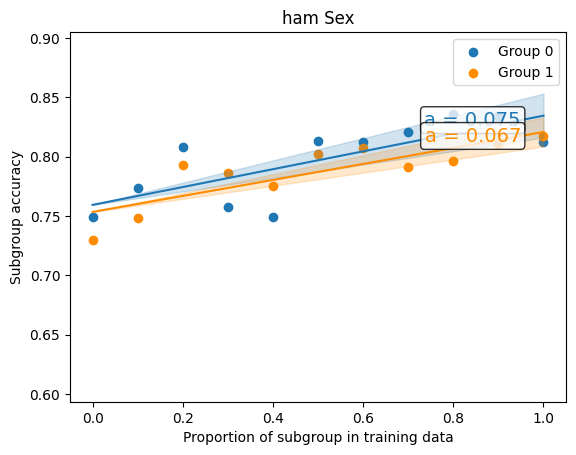

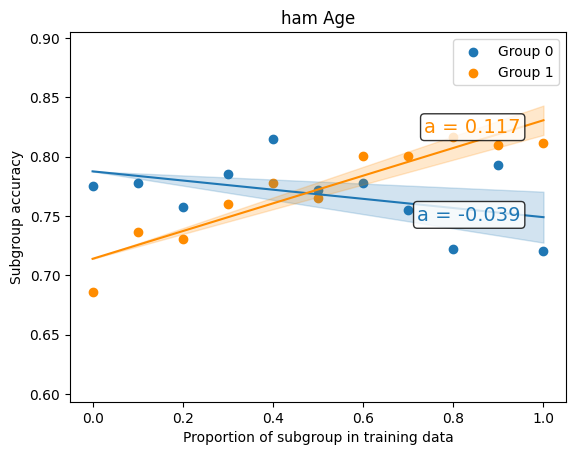

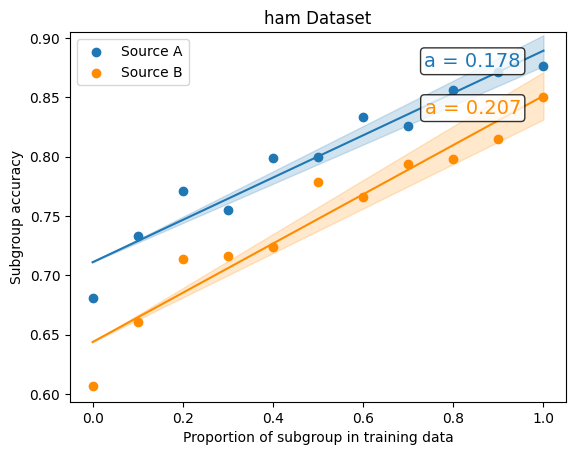

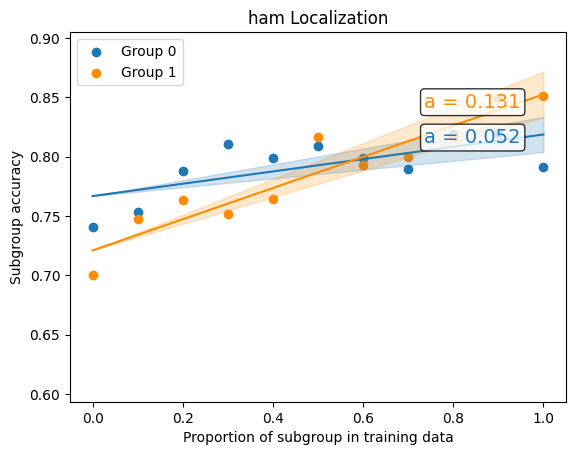

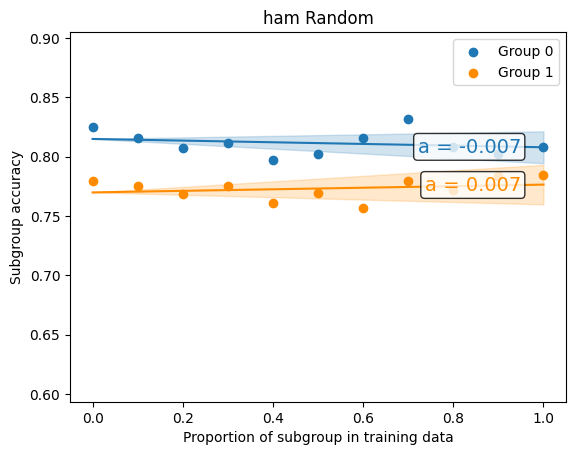

In [23]:
metric = 'balanced_acc'

min_val = min(all_runs_df[metric+'_group_0'].min(), all_runs_df[metric+'_group_1'].min())
max_val = max(all_runs_df[metric+'_group_0'].max(), all_runs_df[metric+'_group_1'].max())

filtered_df = all_runs_df.copy()

plot_slope(filtered_df, summary_df, metric, min_val, max_val, dataset)

In [51]:
metrics = ['auc', 'balanced_acc','acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()

slopes_df = get_slopes_df(all_runs_df, metrics, subgroups)

In [52]:
slopes_df = slopes_df.merge(emd_df,on='subgroup')
slopes_df = slopes_df.rename(columns={col: col.replace("FID", "FD") for col in slopes_df.columns if "FID" in col})
slopes_df = slopes_df.rename(columns={col: col.replace("TVD", "TV") for col in slopes_df.columns if "TVD" in col})

## Correlation: representation distance vs allocation sensitivity

Also look at correlation between loss slope and generalisation (full shot performance minus zero shot performance).

0.31005851354839264
0.06450404785363709
0.07102716813183804


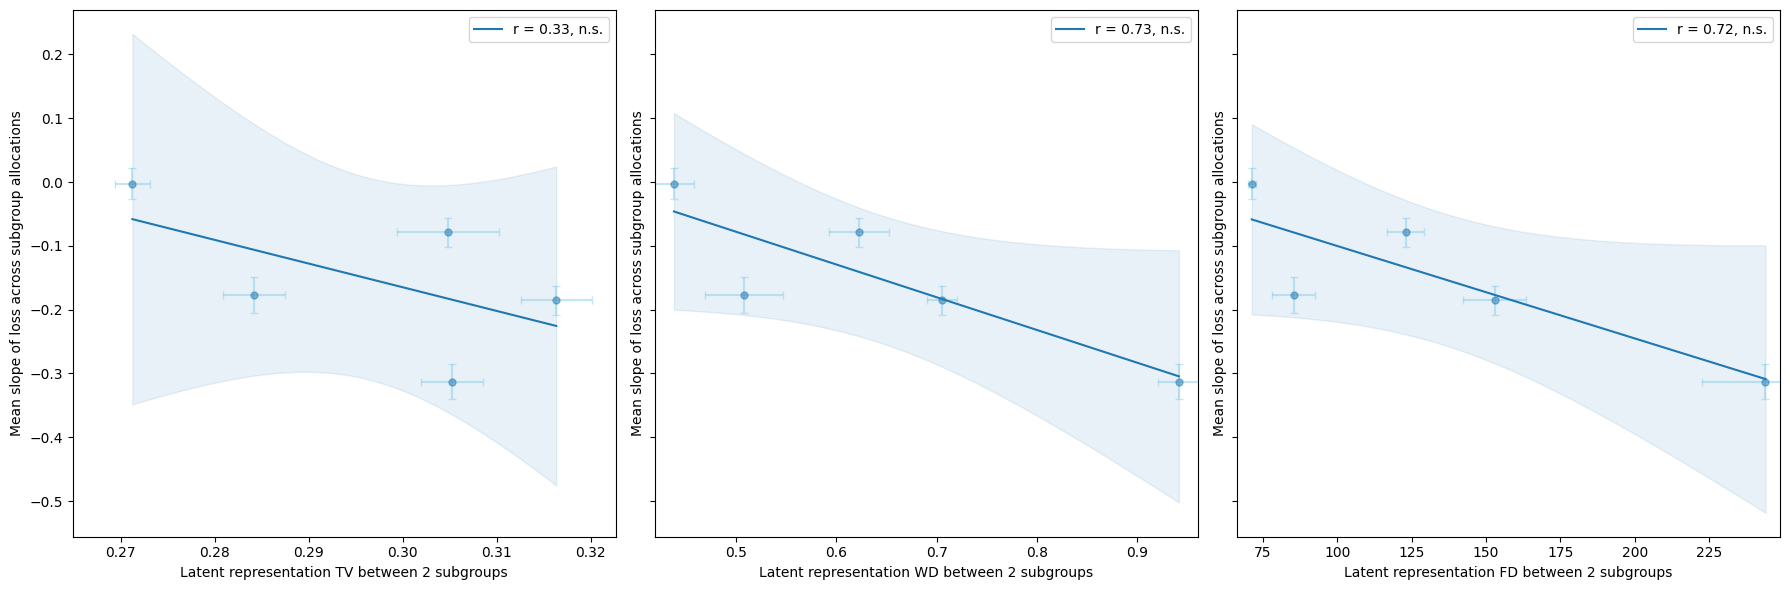

0.3279995793989536
0.09874561931629301
0.10536633501712432


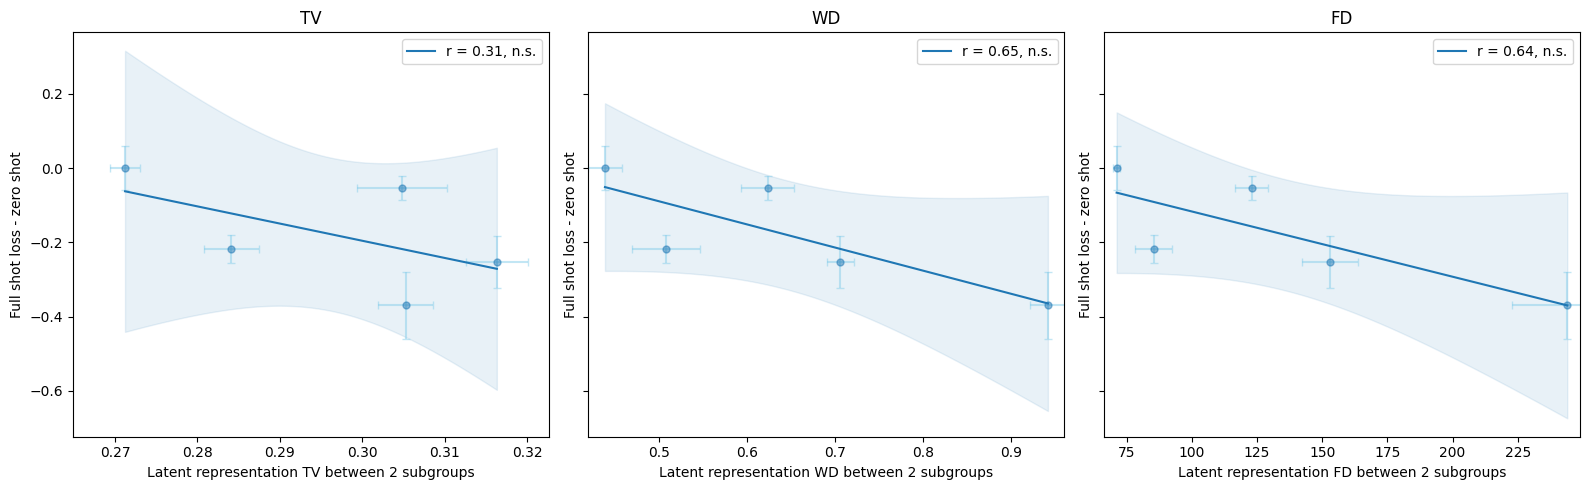

In [53]:
distance_metrics = ['TV','WD','FD']
metric = 'loss'

plot_distance_slope(slopes_df, distance_metrics,metric)
plot_distance_generalisation(slopes_df, distance_metrics,metric)


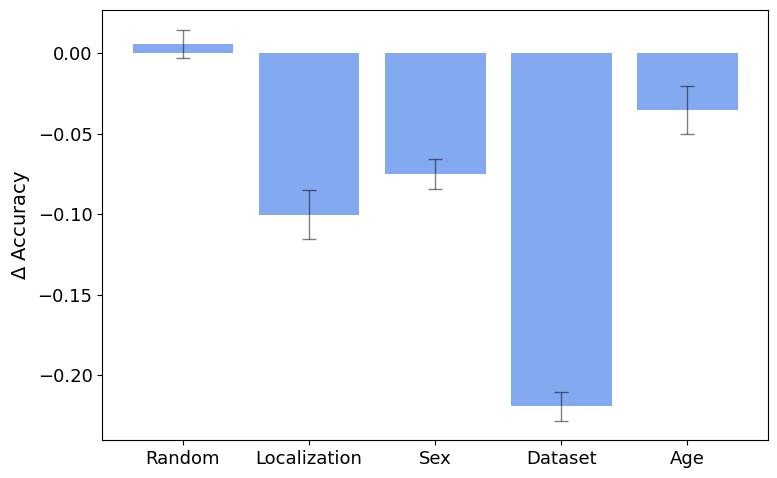

In [ ]:
metric = 'balanced_acc'  # can also be 'auc' or 'balanced_acc'

diff_col = f'{metric}_diff_mean'
std_col = f'{metric}_diff_std'

# Sort subgroups by WD_g0_vs_g1_mean
sorted_df = slopes_df.sort_values('TV_g0_vs_g1_mean')
# sorted_df.set_index('subgroup',inplace=True)
x_pos = np.arange(len(sorted_df))
plt.figure(figsize=(8, 5))
plt.bar(x_pos, -sorted_df[diff_col], yerr=sorted_df[std_col], 
        capsize=5, color='cornflowerblue', alpha=0.8,error_kw={'alpha':0.5, 'lw':1})
# y_arrow = min(-sorted_df[diff_col]) - 0.01  # position below bars
plt.ylabel(f'$\Delta$ Accuracy')
plt.tight_layout()
plt.xticks(x_pos, sorted_df['subgroup'], rotation=0)
# plt.title('Civil_comments')
plt.savefig(os.path.join(FIGS_DIR, 'scratch_ham_bacc.pdf'),bbox_inches="tight")

plt.show()

## Alternative hypotheses

In [36]:
base_dir = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
required_lr = 0.000065

summary_gap_df = get_baseline_subgroup_df(base_dir,test_metadata_df,attributes,required_lr)
summary_gap_df['subgroup'] = summary_gap_df['subgroup'].str.replace("_binary", "", regex=False)

slopes_df = slopes_df.merge(summary_gap_df,on='subgroup')

In [37]:
group_1_prevalence = []
group_0_prevalence = []
class_prevalence_diffs = []
class_prevalence_group_1 = []
class_prevalence_group_0 = []

for col in slopes_df['subgroup'].tolist():
    subgroup_1_df = train_df[train_df[col + '_binary'] == 1]
    subgroup_0_df = train_df[train_df[col + '_binary'] == 0]

    # fraction of dataset belonging to group 1 vs group 0
    group_1_prevalence.append(len(subgroup_1_df) / len(train_df))
    group_0_prevalence.append(len(subgroup_0_df) / len(train_df))

    # within-group class prevalences
    prev_1 = len(subgroup_1_df[subgroup_1_df['Y'] == 1]) / len(subgroup_1_df)
    prev_0 = len(subgroup_0_df[subgroup_0_df['Y'] == 1]) / len(subgroup_0_df)

    class_prevalence_group_1.append(prev_1)
    class_prevalence_group_0.append(prev_0)

    # absolute difference in positive class prevalence between groups
    class_prevalence_diffs.append(np.abs(prev_1 - prev_0))

slopes_df['group_1_prevalence'] = group_1_prevalence
slopes_df['group_0_prevalence'] = group_0_prevalence
slopes_df['mean_prevalence'] = [np.abs(x-0.5) for x in group_1_prevalence] # gives indication of whether there is imbalance
slopes_df['class_prevalence_group_1'] = class_prevalence_group_1
slopes_df['class_prevalence_group_0'] = class_prevalence_group_0
slopes_df['class_prevalence_diff'] = class_prevalence_diffs

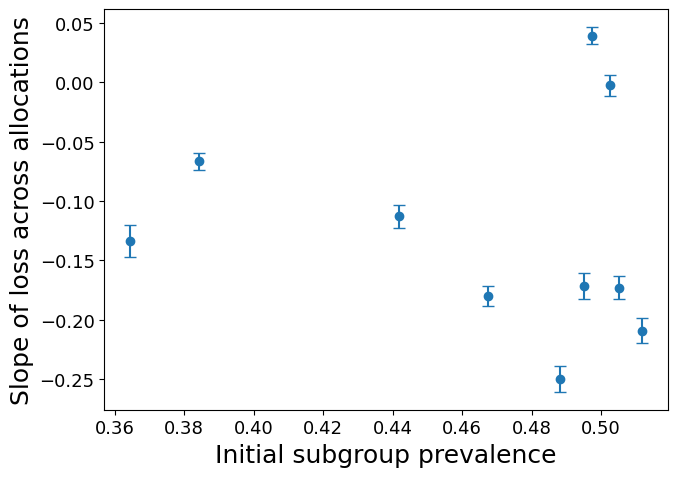

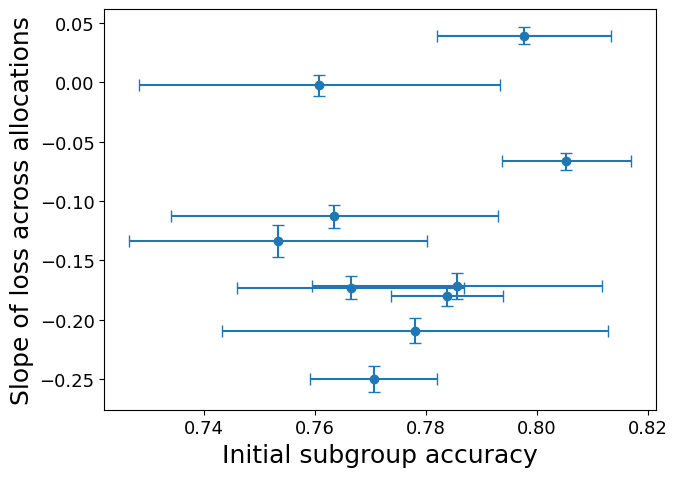

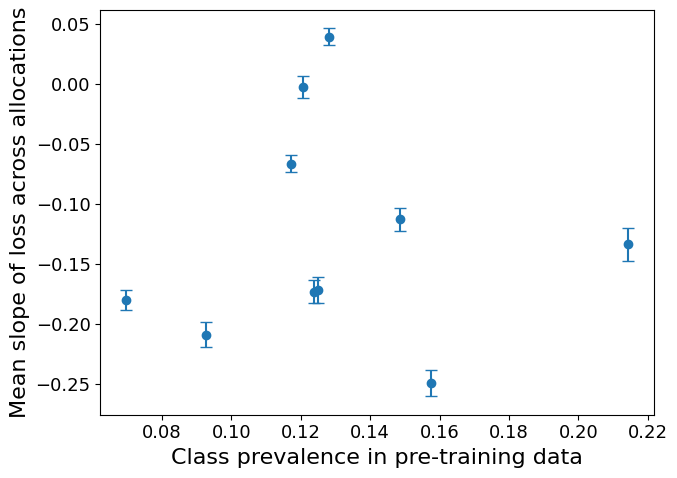

In [38]:
metric = "loss"  # or "balanced_acc", etc.
plt.figure(figsize=(7, 5))

plt.errorbar(
    slopes_df['group_0_prevalence'],
    slopes_df[f'{metric}_slope_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['group_1_prevalence'],
    slopes_df[f'{metric}_slope_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.xlabel("Initial subgroup prevalence",size=18)
plt.ylabel(f"Slope of {metric} across allocations",size=18)
# plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fullft_ham_prevalence.pdf'),bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(
    slopes_df['mean_balanced_acc_group_0'],
    slopes_df[f'{metric}_slope_group_0'],
    xerr=slopes_df['std_balanced_acc_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['mean_balanced_acc_group_1'],
    slopes_df[f'{metric}_slope_group_1'],
    xerr=slopes_df['std_balanced_acc_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.ylabel(f"Slope of {metric} across allocations",size=18)
plt.xlabel("Initial subgroup accuracy",size=18)
# plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fullft_ham_imbalance.pdf'),bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))

plt.errorbar(
    slopes_df['class_prevalence_group_0'],
    slopes_df[f'{metric}_slope_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['class_prevalence_group_1'],
    slopes_df[f'{metric}_slope_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.xlabel("Class prevalence in pre-training data")
plt.ylabel(f"Mean slope of {metric} across allocations")
# plt.legend()
plt.tight_layout()
# plt.title('Civil_comments')
plt.savefig(os.path.join(FIGS_DIR, 'fullft_ham_class_prevalence.pdf'),bbox_inches="tight")
plt.show()

## Upper bound

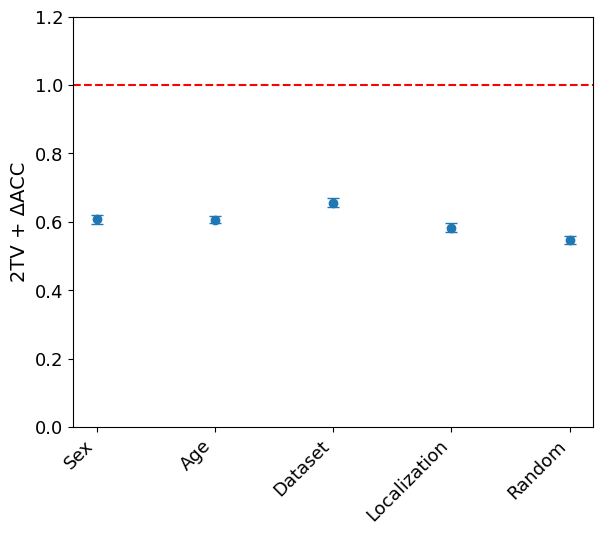

In [183]:
slopes_df['2TV+Δacc_mean'] = 2 * slopes_df['TV_g0_vs_g1_mean'] + slopes_df['balanced_acc_diff_mean']
slopes_df['2TV+Δacc_std']  = (2 * slopes_df['TV_g0_vs_g1_std']**2 + slopes_df['balanced_acc_diff_std']**2)**0.5  # rough propagated std

plt.errorbar(slopes_df['subgroup'], slopes_df['2TV+Δacc_mean'],
             yerr=slopes_df['2TV+Δacc_std'], fmt='o', capsize=4)
plt.axhline(1.0, color='r', linestyle='--', label='bound = 1')
plt.ylabel('2TV + ΔACC')
plt.tight_layout()
plt.ylim([0,1.2])
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(FIGS_DIR, 'upperbound_ham.pdf'), dpi=200,bbox_inches='tight')
plt.show()



# CIVIL COMMENTS

In [54]:
PRETRAINED=True
dataset='Civilcomments'
label='toxicity'
model = 'bert'

test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/CIVILCOMMENTS/test_labels.csv'))
train_df = pd.read_csv(os.path.join(BASE_DIR, 'data/CIVILCOMMENTS/train_labels_pretrain.csv'))

loss = torch.nn.CrossEntropyLoss()

attributes = ['Gender_binary', 'Orientation_binary', 'Religion_binary', 'Race_binary', 'Year_binary', 'Random_binary']
proportions = range(0, 101, 10)
max_count = 9

# Experiment type: choose one
# experiment_string = 'llrt_val_acc_alloc'  # LLRT (main experiments)
# experiment_string = 'finetune_alloc'    # Full fine-tuning
experiment_string = 'scratch_alloc'     # Training from scratch

if experiment_string == 'scratch_alloc':
    required_lr = 0.000222
    emd_df = pd.read_csv(os.path.join(RESULTS_DIR, f'civilcomments/{model.lower()}/scratch_mean_distances.csv'))
else:  # LLRT or full fine-tuning
    required_lr = 0.0006
    emd_df = pd.read_csv(os.path.join(RESULTS_DIR, f'civilcomments/{model.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))
emd_df['subgroup'] = emd_df['Unnamed: 0']

required_data_name = 'CIVILCOMMENTS'


In [55]:
all_runs_df, summary_df = get_summary_df(experiment_string, test_metadata_df, required_lr, required_data_name, attributes)

Skipping: logs/scratch_alloc_Gender_binary_0/runs/2025-11-14_23-44-42-543132/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_0/runs/2025-11-14_23-46-38-916379/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_0/runs/2025-11-14_23-42-44-027938/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_10/runs/2025-11-15_00-17-17-517204/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_10/runs/2025-11-15_00-21-03-265141/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_10/runs/2025-11-15_00-19-05-640759/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_20/runs/2025-11-14_23-47-44-639987/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_20/runs/2025-11-14_23-45-52-807913/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_20/runs/2025-11-14_23-43-56-125800/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_30/runs/2025-11-15_00-19-05-648415/preds.csv
Skipping: logs/scratch_alloc_Gender_binary_30/runs/2025-11-15_00-20-53-197169/preds.csv
Skipping: logs/scratch_alloc_Gender

## Allocation sensitivity

/gpfs3/well/papiez/users/hri611/python/data-centric-bias/src/utils/analysis_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgroup_df.sort_values(by='proportion', inplace=True)


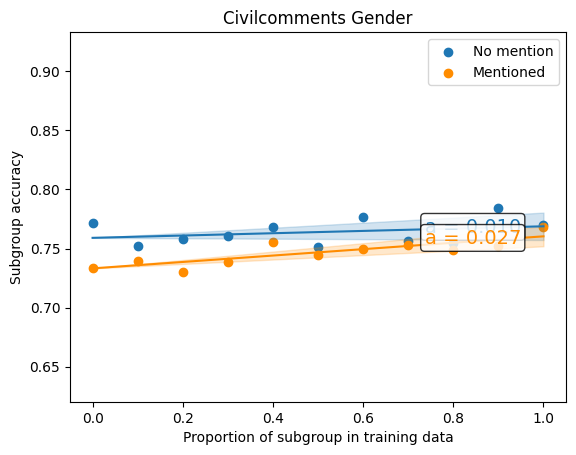

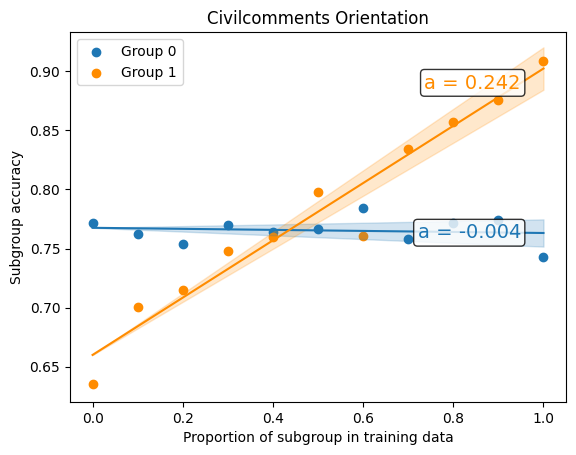

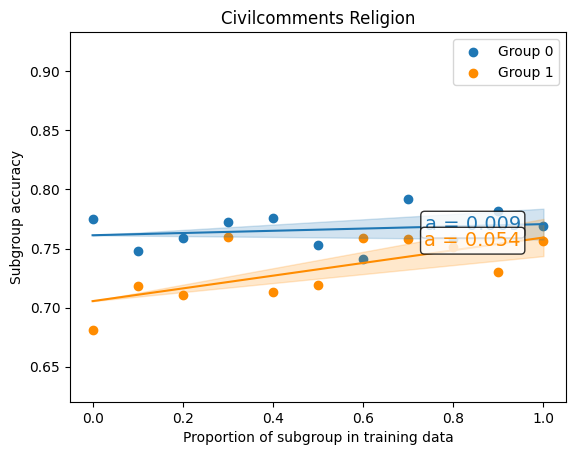

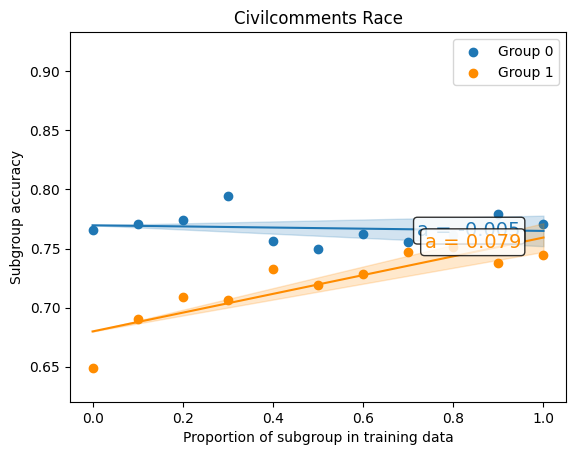

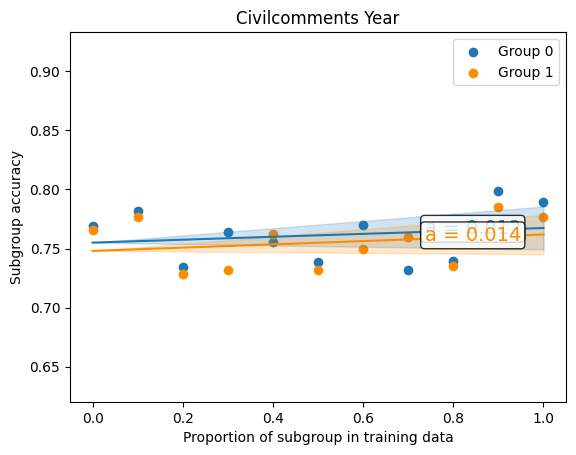

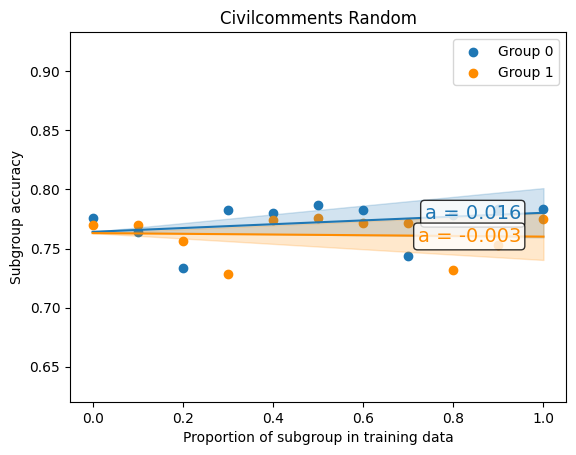

In [56]:
metric = 'balanced_acc'

min_val = min(all_runs_df[metric+'_group_0'].min(), all_runs_df[metric+'_group_1'].min())
max_val = max(all_runs_df[metric+'_group_0'].max(), all_runs_df[metric+'_group_1'].max())

filtered_df = all_runs_df.copy()

plot_slope(filtered_df, summary_df, metric, min_val, max_val, dataset)

In [57]:
metrics = ['auc', 'balanced_acc','acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()

slopes_df = get_slopes_df(all_runs_df, metrics, subgroups)

In [58]:

slopes_df = slopes_df.merge(emd_df,on='subgroup')
slopes_df = slopes_df.rename(columns={col: col.replace("FID", "FD") for col in slopes_df.columns if "FID" in col})
slopes_df = slopes_df.rename(columns={col: col.replace("TVD", "TV") for col in slopes_df.columns if "TVD" in col})

## Correlation: representation distance vs allocation sensitivity

Also look at correlation between loss slope and generalisation (full shot performance minus zero shot performance).

0.013252418603063355
0.026738700854680154
0.001674605648128648


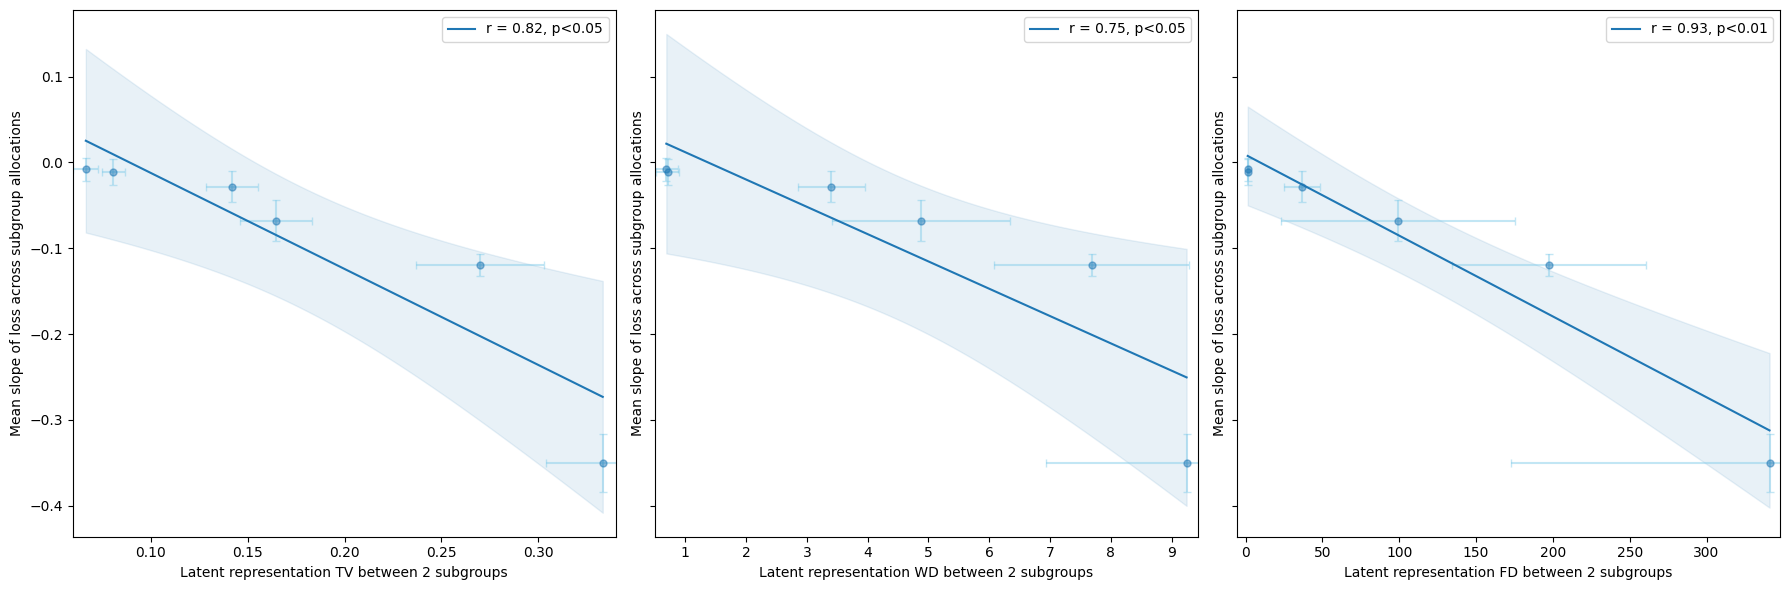

0.015502127762574845
0.032122202636404334
0.00228876641850977


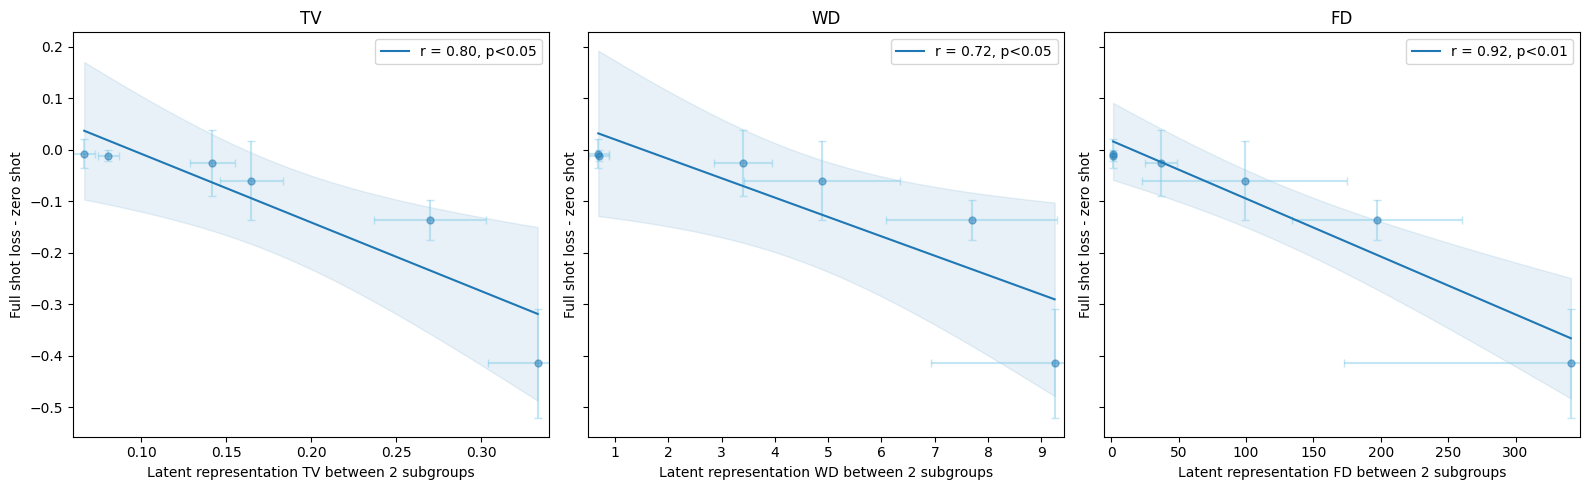

In [59]:
distance_metrics = ['TV','WD','FD']
metric = 'loss'

plot_distance_slope(slopes_df, distance_metrics,metric)
plot_distance_generalisation(slopes_df, distance_metrics,metric)

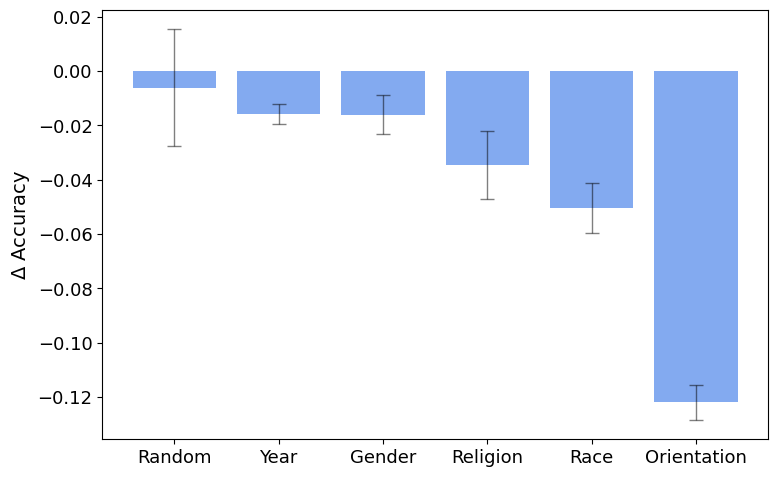

In [152]:
metric = 'balanced_acc'  # can also be 'auc' or 'balanced_acc'

diff_col = f'{metric}_diff_mean'
std_col = f'{metric}_diff_std'

# Sort subgroups by WD_g0_vs_g1_mean
sorted_df = slopes_df.sort_values('TV_g0_vs_g1_mean')
# sorted_df.set_index('subgroup',inplace=True)
x_pos = np.arange(len(sorted_df))
plt.figure(figsize=(8, 5))
plt.bar(x_pos, -sorted_df[diff_col], yerr=sorted_df[std_col], 
        capsize=5, color='cornflowerblue', alpha=0.8,error_kw={'alpha':0.5, 'lw':1})
# y_arrow = min(-sorted_df[diff_col]) - 0.01  # position below bars
plt.ylabel(f'$\Delta$ Accuracy')
plt.tight_layout()
plt.xticks(x_pos, sorted_df['subgroup'], rotation=0)
# plt.title('Civil_comments')
plt.savefig(os.path.join(FIGS_DIR, 'scratch_civilcomments_bacc.pdf'),bbox_inches="tight")

plt.show()

## Alternative hypotheses

In [45]:
base_dir = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
required_lr = 0.000222

summary_gap_df = get_baseline_subgroup_df(base_dir,test_metadata_df,attributes,required_lr)
summary_gap_df['subgroup'] = summary_gap_df['subgroup'].str.replace("_binary", "", regex=False)

slopes_df = slopes_df.merge(summary_gap_df,on='subgroup')

In [46]:
group_1_prevalence = []
group_0_prevalence = []
class_prevalence_diffs = []
class_prevalence_group_1 = []
class_prevalence_group_0 = []

for col in slopes_df['subgroup'].tolist():
    subgroup_1_df = train_df[train_df[col + '_binary'] == 1]
    subgroup_0_df = train_df[train_df[col + '_binary'] == 0]

    # fraction of dataset belonging to group 1 vs group 0
    group_1_prevalence.append(len(subgroup_1_df) / len(train_df))
    group_0_prevalence.append(len(subgroup_0_df) / len(train_df))

    # within-group class prevalences
    prev_1 = len(subgroup_1_df[subgroup_1_df['Y'] == 1]) / len(subgroup_1_df)
    prev_0 = len(subgroup_0_df[subgroup_0_df['Y'] == 1]) / len(subgroup_0_df)

    class_prevalence_group_1.append(prev_1)
    class_prevalence_group_0.append(prev_0)

    class_prevalence_diffs.append(np.abs(prev_1 - prev_0))

# save into slopes_df
slopes_df['group_1_prevalence'] = group_1_prevalence
slopes_df['group_0_prevalence'] = group_0_prevalence
slopes_df['mean_prevalence'] = [np.abs(x-0.5) for x in group_1_prevalence] # gives indication of whether there is imbalance
slopes_df['class_prevalence_group_1'] = class_prevalence_group_1
slopes_df['class_prevalence_group_0'] = class_prevalence_group_0
slopes_df['class_prevalence_diff'] = class_prevalence_diffs

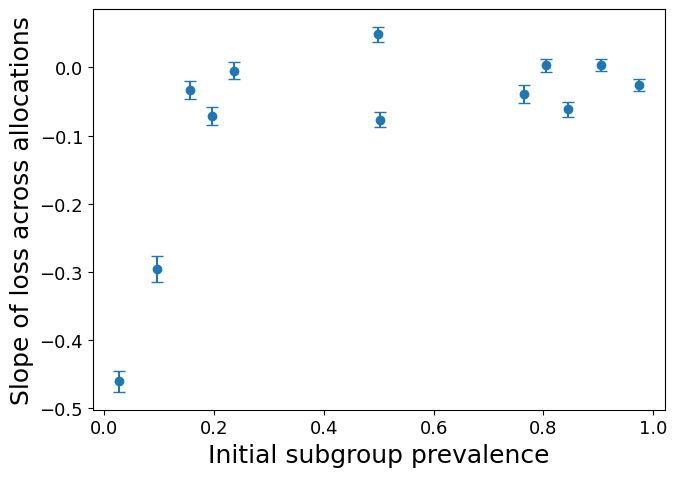

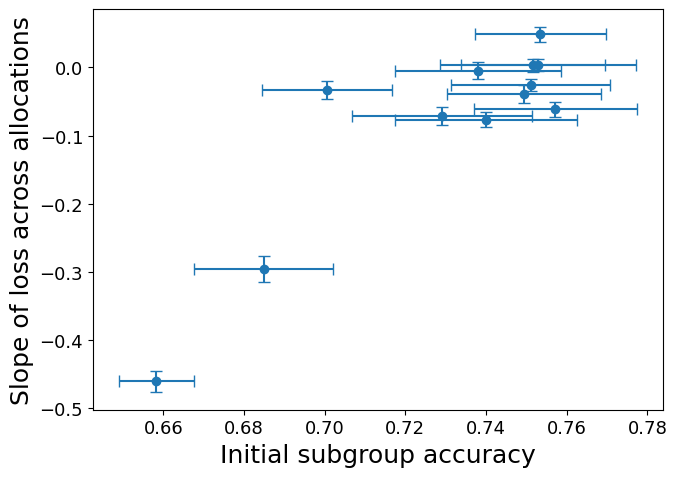

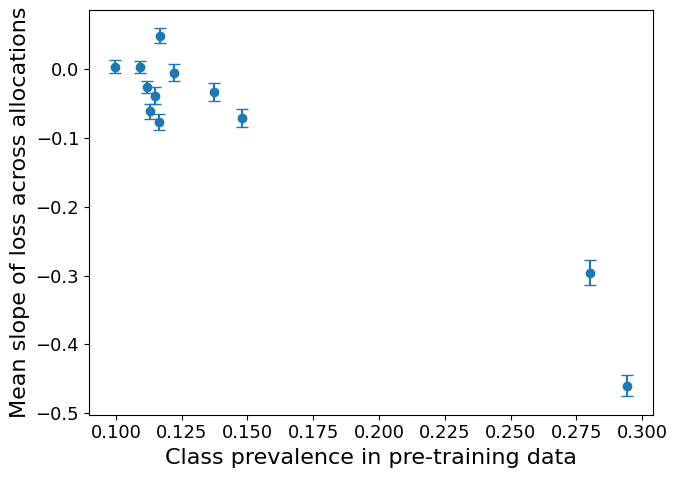

In [47]:
metric = "loss"  # or "balanced_acc", etc.
plt.figure(figsize=(7, 5))

plt.errorbar(
    slopes_df['group_0_prevalence'],
    slopes_df[f'{metric}_slope_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['group_1_prevalence'],
    slopes_df[f'{metric}_slope_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.xlabel("Initial subgroup prevalence",size=18)
plt.ylabel(f"Slope of {metric} across allocations",size=18)
# plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fullft_civilcomments_prevalence.pdf'),bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(
    slopes_df['mean_balanced_acc_group_0'],
    slopes_df[f'{metric}_slope_group_0'],
    xerr=slopes_df['std_balanced_acc_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['mean_balanced_acc_group_1'],
    slopes_df[f'{metric}_slope_group_1'],
    xerr=slopes_df['std_balanced_acc_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.ylabel(f"Slope of {metric} across allocations",size=18)
plt.xlabel("Initial subgroup accuracy",size=18)
# plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fullft_civilcomments_imbalance.pdf'),bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))

plt.errorbar(
    slopes_df['class_prevalence_group_0'],
    slopes_df[f'{metric}_slope_group_0'],
    yerr=slopes_df[f'{metric}_slope_group_0_std'],
    fmt='o',
    capsize=4,
    label="Group 0",
    color="tab:blue"
)
plt.errorbar(
    slopes_df['class_prevalence_group_1'],
    slopes_df[f'{metric}_slope_group_1'],
    yerr=slopes_df[f'{metric}_slope_group_1_std'],
    fmt='o',
    capsize=4,
    label="Group 1",
    color="tab:blue"
)
plt.xlabel("Class prevalence in pre-training data")
plt.ylabel(f"Mean slope of {metric} across allocations")
# plt.legend()
plt.tight_layout()
# plt.title('Civil_comments')
plt.savefig(os.path.join(FIGS_DIR, 'fullft_civilcomments_class_prevalence.pdf'),bbox_inches="tight")
plt.show()

## Upper bound

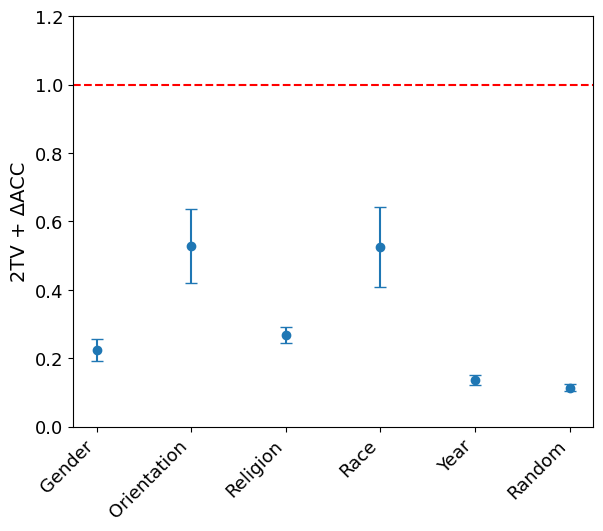

In [193]:
slopes_df['2TV+Δacc_mean'] = 2 * slopes_df['TV_g0_vs_g1_mean'] + slopes_df['balanced_acc_diff_mean']
slopes_df['2TV+Δacc_std']  = (2 * slopes_df['TV_g0_vs_g1_std']**2 + slopes_df['balanced_acc_diff_std']**2)**0.5  # rough propagated std

plt.errorbar(slopes_df['subgroup'], slopes_df['2TV+Δacc_mean'],
             yerr=slopes_df['2TV+Δacc_std'], fmt='o', capsize=4)
plt.axhline(1.0, color='r', linestyle='--', label='bound = 1')
plt.ylabel('2TV + ΔACC')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.ylim([0,1.2])
plt.savefig(os.path.join(FIGS_DIR, 'upperbound_civilcomments.pdf'), dpi=200,bbox_inches='tight')
plt.show()
